In [1]:
# Standard python imports.
import matplotlib.pylab as plt
import numpy as np
import photonforge as pf

# Import regular tidy3d
import tidy3d as td
import tidy3d.web as web

In [2]:
# MMI power splitter setup.
wavelength = 1.31  # Center simulation wavelength (um).
freq0 = td.C_0 / wavelength  # Central frequency.

In [101]:
mat_si = td.material_library['cSi']['Li1993_293K']
# mat_si = td.Medium(permittivity=3.48**2)  # Use real permittivity for mode source

mat_sio2 = td.material_library['SiO2']['Horiba']
# mat_sio2 = td.Medium(permittivity=1.44**2)  # Use real permittivity for mode source

In [102]:
# This cell contains all the geometry, sources, monitors, and simulation creation

# MMI power splitter dimensions.
w_wg = 0.38  # Waveguide width (um).
h_si = 0.22  # Silicon layer height (um).
gap = 0.1  # Gap between output waveguides (um).

# S-bend parameters.
s_bend_offset = 1.0  # Lateral offset for S-bends (um).
s_bend_length = 10.0  # Length of S-bend section (um).

In [103]:
def y_at_x(spine, x_query):
    spine = np.array(spine)

    x = spine[:, 0]
    y = spine[:, 1]

    # Ensure monotonicity in x (important)
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    return np.interp(x_query, x, y)

In [104]:
def point_at_ymax(spine):
    spine = np.array(spine)

    x = spine[:, 0]
    y = spine[:, 1]

    # Ensure monotonicity in x (important)
    ymax_idx = np.argmax(y)

    print(x[ymax_idx], y[ymax_idx])
    print(x[ymax_idx-1], y[ymax_idx-1])
    print(x[ymax_idx+1], y[ymax_idx+1])
    

    return x[ymax_idx], y[ymax_idx]

In [105]:
import numpy as np

def compute_tangent(x, y):
    dx = np.gradient(x)
    dy = np.gradient(y)
    
    theta = np.arctan2(dy, dx)  # robust version
    
    return theta

In [106]:
def compute_arclength(x, y):
    ds = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    s = np.concatenate([[0], np.cumsum(ds)])
    return s

In [107]:
def compute_arclength(x, y):
    ds = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    s = np.concatenate([[0], np.cumsum(ds)])
    return s

In [108]:
def make_bent_dc_shape(    # angle in degrees
    w_wg: float,
    gap: float,
    s_bend_length: float,
    s_bend_offset: float,
    R_inner: float = 25.0,
    theta_deg: float = 10.0,
    center: tuple[float, float]=(0, 0),
    slab_bounds: tuple[float, float]=(-0.11, 0.11),
    sidewall_angle: float=0,
    reference_plane: str="top",
) -> td.PolySlab:
    """
    This version has s-bends directly after the arc, without a correcting arc to make the bends start vertically.
    """

    theta_rad = np.radians(theta_deg)
    y1 = R_inner * (1 - np.cos(theta_rad/2))
    y_up = - y1 + s_bend_offset + w_wg/2 + gap/2
    y_down = - y1 - s_bend_offset - w_wg/2 - gap/2

    total_offset = y_up - y_down

    # bend_out_up = pf.Path(origin=(0, w_wg/2 + gap/2), width=w_wg)
    bend_out_up = pf.Path(origin=(0, y1 + w_wg/2 + gap/2), width=w_wg)
    
    bend_out_up.arc(
        initial_angle=90, final_angle=90 - theta_deg/2,
        radius=R_inner + w_wg/2 + gap/2, rotation=0, euler_fraction=0, width=w_wg)
    bend_out_up.s_bend(endpoint=(s_bend_length, s_bend_offset),
                       relative=True, euler_fraction=1)
    bend_out_up.arc(
        initial_angle=270 - theta_deg/2, final_angle=270,
        radius=R_inner + w_wg/2 + gap/2, rotation=0, euler_fraction=1, width=w_wg)
    bend_out_up.segment(endpoint=(5, 0), relative=True)

    bend_out_down = pf.Path(origin=(0, y1 -(w_wg/2 + gap/2)), width=w_wg)
    bend_out_down.arc(
        initial_angle=90, final_angle=90 - theta_deg/2,
        radius=R_inner - w_wg/2 - gap/2, rotation=0, euler_fraction=0, width=w_wg)
    bend_out_down.s_bend(endpoint=(s_bend_length, - s_bend_offset),
                       relative=True, euler_fraction=1)
    bend_out_down.arc(
        initial_angle=270 - theta_deg/2, final_angle=270,
        radius=R_inner - w_wg/2 - gap/2, rotation=0, euler_fraction=1, width=w_wg)
    bend_out_down.segment(endpoint=(5, 0), relative=True)


    bend_in_up = bend_out_up.copy().mirror((0, 1))
    bend_in_down = bend_out_down.copy().mirror((0, 1))

    # Returns a list of Polygon objects, representing the polygons of the Paths successing the boolean operation.
    # The boolean below is the union of the first list with an empty list.
    # So the purpose was more to get the polygons from the Paths.
    polygons_up = pf.boolean(
        [
            bend_out_up,
            bend_in_up
        ],
        [],
        "+",
    )
    polygons_down = pf.boolean(
          [
            bend_out_down,
            bend_in_down
          ], [], "+")  # Empty union to get an empty list of polygons.

    # assert len(polygons) == 2, "Expected two polygon for the union."
    # polygon = polygons[0]
    # assert len(polygon.holes) == 0, "Expected no holes."
    polygon_up = polygons_up[0]
    polygon_down = polygons_down[0]
    polygon_up.translate(center)
    polygon_down.translate(center)

    # Polygon extruded with optional sidewall angle along axis direction.
    geometry_up = td.PolySlab(
        vertices=polygon_up.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    geometry_down = td.PolySlab(
        vertices=polygon_down.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    import matplotlib.pyplot as plt

    x1 = bend_out_up.spine()[:, 0]
    y1 = bend_out_up.spine()[:, 1]

    x2 = np.flip(bend_in_up.spine()[:, 0])
    y2 = np.flip(bend_in_up.spine()[:, 1])

    x = np.concatenate([x2, x1])
    y = np.concatenate([y2, y1])

    print(np.all(np.diff(x) >= 0))
    
    theta = compute_tangent(x, y)
    s = compute_arclength(x, y)

    plt.figure()
    plt.plot(s, theta, 'o-')
    plt.xlabel("Arc length (μm)")
    plt.ylabel("Tangent angle (rad)")
    plt.title("Tangent angle along waveguide")
    plt.grid()
    plt.show()

    # plt.figure()
    # plt.scatter(x, y)
    # plt.xlabel("x (μm)")
    # plt.ylabel("y (μm)")
    # plt.title("Coordinates")
    # plt.grid()
    # plt.show()

    x1 = bend_out_down.spine()[:, 0]
    y1 = bend_out_down.spine()[:, 1]
    x2 = np.flip(bend_in_down.spine()[:, 0])
    y2 = np.flip(bend_in_down.spine()[:, 1])
    x = np.concatenate([x2, x1])
    y = np.concatenate([y2, y1])

    theta = compute_tangent(x, y)
    s = compute_arclength(x, y)

    plt.figure()
    plt.plot(s, theta, 'o-')
    plt.xlabel("Arc length (μm)")
    plt.ylabel("Tangent angle (rad)")
    plt.title("Tangent angle along waveguide")
    plt.grid()
    plt.show()


    x_end_up = bend_out_up.spine()[-1][0]
    y_end_up = bend_out_up.spine()[-1][1]

    x_end_down = bend_out_down.spine()[-1][0]
    y_end_down = bend_out_down.spine()[-1][1]

    print(f"Up bend end: ({x_end_up}, {y_end_up})")

    print(bend_out_up.spine()[-1], bend_in_up.spine()[-1])
    print(bend_out_up.spine()[0], bend_in_up.spine()[0])

    return geometry_up, geometry_down, x_end_up, y_end_up, x_end_down, y_end_down

Calculated s-bend offset: 10.00 μm
True


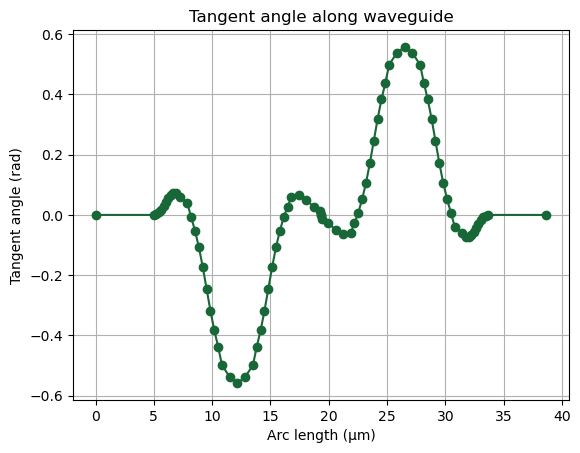

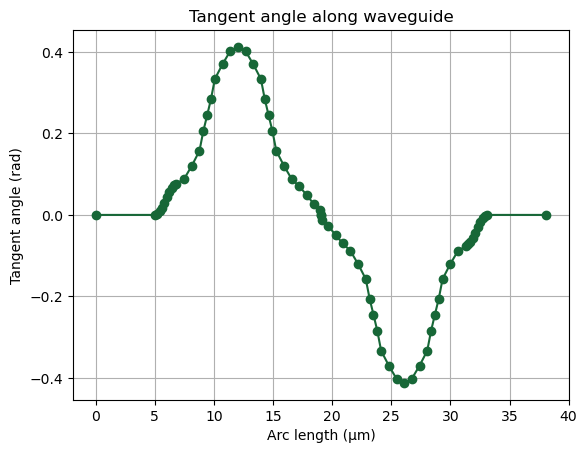

Up bend end: (18.741000000000003, 2.6700000000000004)
[18.741  2.67 ] [-18.741   2.67 ]
[0.    0.309] [0.    0.309]


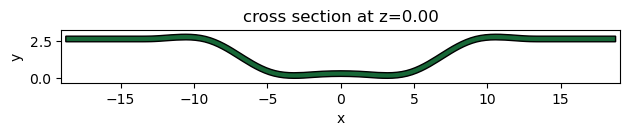

In [159]:
R_inner = 25.0
theta_deg = 8.5
s_bend_length = 10

s_bend_radius = 5
theta = np.arcsin(s_bend_length/2 / s_bend_radius)

s_bend_offset = 2 * s_bend_radius * (1 - np.cos(theta))
print(f"Calculated s-bend offset: {s_bend_offset:.2f} μm")
s_bend_offset = 2.5

geometry_up, geometry_down, x_end_up, y_end_up, x_end_down, y_end_down = make_bent_dc_shape(
    R_inner=R_inner, theta_deg=theta_deg,
    w_wg=w_wg, gap=gap, s_bend_length=s_bend_length, s_bend_offset=s_bend_offset)

# Turning geometry to structure
mmi_structure_up = td.Structure(geometry=geometry_up, medium=mat_si)
mmi_structure_down = td.Structure(geometry=geometry_down, medium=mat_si)
ax = mmi_structure_up.plot(z=0)

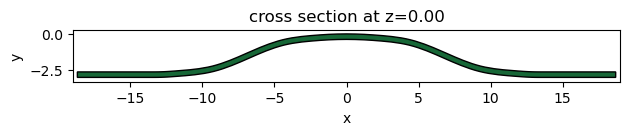

In [160]:
ax = mmi_structure_down.plot(z=0)


In [161]:
# Calculate optimized simulation domain size for x-axis propagation.
total_length = 2 * x_end_up - 5.0  # Keep length buffer for source and monitors
total_width = y_end_up - y_end_down + 4.0  # Keep width buffer for offset waveguides
total_height = 2.0  # Sufficient for SOI structure
sim_size_optimized = (total_length, total_width, total_height)

wavelengths = np.arange(1.27, 1.35, 0.01)  # 1.27 to 1.35 μm with 10 nm steps
frequencies = td.C_0 / wavelengths

# ===================
# Source Definition
# source_position = (-(x_at_ymax_up), y_at_ymax_up, 0)
source_position = (-(x_end_up - 4.0), y_end_up, 0)
source_size = (0, 6 * w_wg, 6 * h_si)
for i, (s, sim) in enumerate(zip(source_size, sim_size_optimized)):
    assert s <= sim, f"Dimension {i} too large: {s} > {sim}"

mode_source = td.ModeSource(
    center=source_position,
    size=source_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)
# ===================

# ===================
# Monitors Definition
# 1) Through monitor
monitor_1_position = (x_end_up - 4.0, y_end_up, 0)
mode_monitor_1 = td.ModeMonitor(
    center=monitor_1_position,
    size=source_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_1",
)
# 2) Cross monitor
monitor_2_position = (x_end_down - 4.0, y_end_down, 0)
mode_monitor_2 = td.ModeMonitor(
    center=monitor_2_position,
    size=source_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_2",
)
# 3) "cross-section" monitor to visualize field distribution throughout the MMI.
# 11. Field monitor at xy plane - record fields at specific wavelengths (x-axis propagation).
field_freqs = [td.C_0 / wavelengths[-1], td.C_0 / wavelengths[0]]  # 1.55 and 1.58 um
field_monitor = td.FieldMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=field_freqs, name="field_xy"
)

In [162]:
# 12. Create the complete simulation.
sim_mmi = td.Simulation(
    size=sim_size_optimized,
    structures=[mmi_structure_up, mmi_structure_down],
    sources=[mode_source],
    monitors=[mode_monitor_1, mode_monitor_2, field_monitor],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=mat_sio2,
    grid_spec=td.GridSpec(
        grid_x=td.AutoGrid(min_steps_per_wvl=20),
        grid_y=td.AutoGrid(min_steps_per_wvl=20),
        grid_z=td.AutoGrid(min_steps_per_wvl=20),
        wavelength=wavelength,
    ),
    symmetry=(0, 0, 0),
)

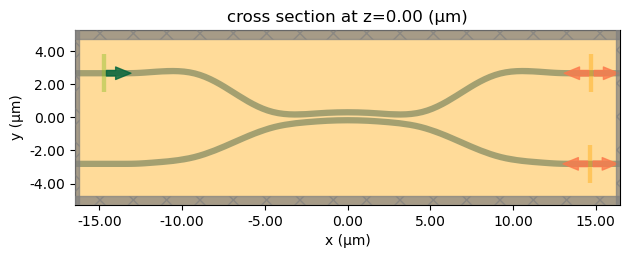

In [163]:
# Simulation Setup Visualization - XY Setup Plane
fig_xy = sim_mmi.plot(z=0)  # XY cross-section at z=0 (MMI center) - shows complete setup

In [164]:
fig_3d = sim_mmi.plot_3d()


In [165]:
# Run Simulation
job = web.Job(simulation=sim_mmi, task_name="dc_bent", verbose=True)

sim_data = job.run(path="dc_bent_results.hdf5")

14:47:58 CEST Created task 'dc_bent' with resource_id                           
              'fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=540654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=339162;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\taskId]8;;\]8;id=540654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\=]8;;\]8;id=398899;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\fdve]8;;\]8;id=540654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\-80e3b48f-60]8;;\
              ]8;id=540654;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\58-40e3-95d7-b3c81850f07a']8;;\.

              Task folder: ]8;id=629972;https://tidy3d.simulation.cloud/folders/folder-10af35a0-4301-429f-8f58-92ff8fc0d7d9\'default']8;;\.

Output()

14:48:03 CEST Estimated FlexCredit cost: 0.968. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

...

Output()

14:49:54 CEST status = success

14:49:56 CEST View simulation result at                                         
              ]8;id=892449;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=940675;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\taskId]8;;\]8;id=892449;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\=]8;;\]8;id=633024;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\fdve]8;;\]8;id=892449;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\-80e3b48f-60]8;;\
              ]8;id=892449;https://tidy3d.simulation.cloud/workbench?taskId=fdve-80e3b48f-6058-40e3-95d7-b3c81850f07a\58-40e3-95d7-b3c81850f07a']8;;\.

Output()

14:50:12 CEST Loading simulation from dc_bent_results.hdf5

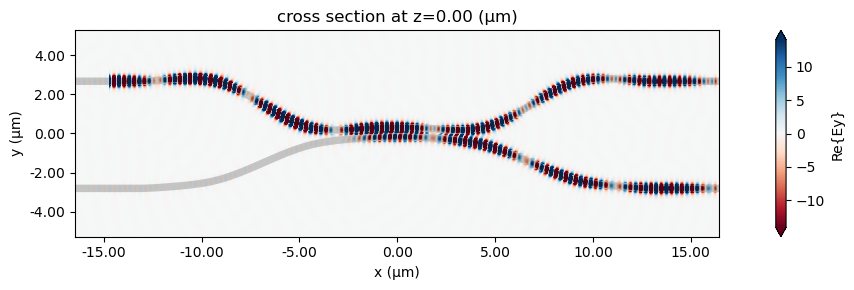

In [166]:
fig, ax = plt.subplots(1,1,figsize=(12, 3), tight_layout=True)

sim_data.plot_field('field_xy', 'Ey', z=0, f=freq0, val='real', ax = ax)
# sim_point_data.plot_field('field', 'Ey', z=0, f=freq0, val='real', ax = ax[1])
# ax[0].set_xlim([-10,0])
# ax[1].set_xlim([-10,0])
plt.show()

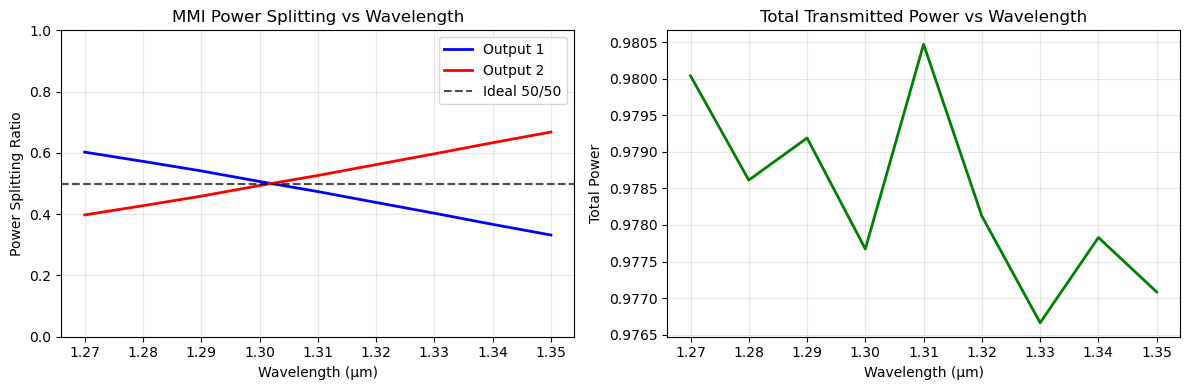

Average splitting ratio 1: 0.471
Average splitting ratio 2: 0.529
Average total power: 0.978


In [167]:
# Extract mode coefficients from ModeMonitors
mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")

# Calculate power splitting
power_1 = np.abs(mode_coeff_1) ** 2
power_2 = np.abs(mode_coeff_2) ** 2
total_power = power_1 + power_2

# Calculate splitting ratio
splitting_ratio_1 = power_1 / total_power
splitting_ratio_2 = power_2 / total_power

# Ensure arrays are numpy arrays for consistent indexing
splitting_ratio_1 = np.array(splitting_ratio_1)
splitting_ratio_2 = np.array(splitting_ratio_2)
total_power = np.array(total_power)

# Create comprehensive analysis plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Power splitting vs wavelength
ax1.plot(wavelengths, splitting_ratio_1, "b-", label="Output 1", linewidth=2)
ax1.plot(wavelengths, splitting_ratio_2, "r-", label="Output 2", linewidth=2)
ax1.axhline(y=0.5, color="k", linestyle="--", alpha=0.7, label="Ideal 50/50")
ax1.set_xlabel("Wavelength (μm)")
ax1.set_ylabel("Power Splitting Ratio")
ax1.set_title("MMI Power Splitting vs Wavelength")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Total power vs wavelength
ax2.plot(wavelengths, total_power, "g-", linewidth=2)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Total Power")
ax2.set_title("Total Transmitted Power vs Wavelength")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key performance metrics
print(f"Average splitting ratio 1: {splitting_ratio_1.mean():.3f}")
print(f"Average splitting ratio 2: {splitting_ratio_2.mean():.3f}")
print(f"Average total power: {total_power.mean():.3f}")